In [855]:
import os
import sys
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [856]:
from config import config_loader as config_loader
from src.data.preprocessing import load_and_filter_catalog
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

In [857]:
def load_rf_config(project_root):
    import os
    from src.utils.file_utils import create_save_dir, save_args_to_json
    from config.config_loader import load_args_from_yaml


    args = load_args_from_yaml(os.path.join(project_root, 'config/rf.yaml'))

    # 添加 RF 专用字段
    
    feature_cols = [
        'Num', 'Mag_max', 'Mag_mean', 'beta', 'b_lsq', 'a_lsq',
        'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
        'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
        'zvalue'
    ] + [f"T_elaps{Mag}" for Mag in args.Mag_elaps]

    args.feature_cols = list(set(feature_cols))
    args.dMag = 0.1
    args_dict = OmegaConf.to_container(args, resolve=True)
   
    args.save_dir = create_save_dir(os.path.join(project_root,'checkpoints') , model_name='rf',args_dict=args_dict )
    args_dict.pop("save_dir", None)


    for key in list(args_dict.keys()):
        if key in {
            "model", "batch_size", "warmup_ratio", "learning_rate", "weight_decay",
            "scheduler_type", "scheduler_factor", "scheduler_patience", "scheduler_threshold",
            "scheduler_min_lr", "d_model", "d_rnn", "d_inner", "n_layers", "n_head", "d_k",
            "d_v", "t_dropout", "attn_type", "mlp_out", "mlp_dropout", "mlp_hdw", "epochs",
            "cuda_id",
        }:
            del args_dict[key]
    save_args_to_json(args_dict, args.save_dir)
    return args


In [858]:
args = load_rf_config(project_root)

In [859]:
args.save_dir

'/home/yzzhang/pjt/chuandian_eq/checkpoints/rf_88865ad1'

In [860]:
base_dir = os.path.join(project_root,  f"data/{args.dataset}")
df = load_and_filter_catalog(base_dir, Mc=args.Mc)

CSV files found: ['processed_ChinaArray.csv', 'ChinaArray.csv']
Multiple CSV files found. Using processed file: processed_ChinaArray.csv


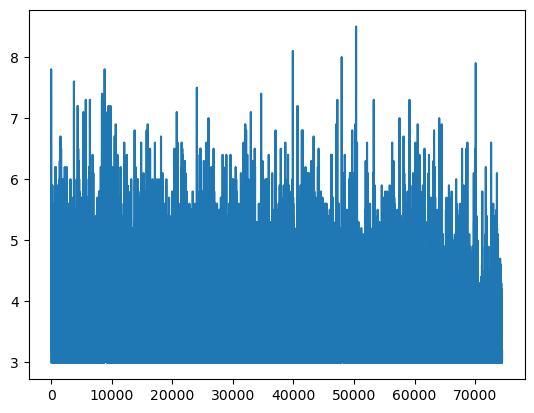

In [861]:
plt.plot(df['Magnitude'])

In [862]:
condition = df['Magnitude'] > args.Mf
changes = condition.ne(condition.shift()).sum()
print(f"Number of changes in condition: {changes}")

Number of changes in condition: 133


In [863]:
import src.features.seismic_features as sf
# features_df, num_mag = sf.calculate_seismic_features(
#     df.to_numpy(), 
#     Mc=args.Mc, 
#     Mf=args.Mf, 
#     Twindow=args.Twindow, 
#     Tfore=args.Tfore, 
#     dt=args.dt, 
#     dMag=args.dMag, 
#     Mag_elaps=args.Mag_elaps, 
#     L_max=60,
#     context_len=args.context_len,
# )

In [864]:
from sklearn.preprocessing import MinMaxScaler

def preprocess_data(features_df, feature_cols):
    # 特征缩放
    scaler = MinMaxScaler()
    feature = scaler.fit_transform(features_df[feature_cols])
    
    # 构造标签
    y = np.full(len(features_df), np.nan)
    y[features_df['shock_len'].values > 0] = 1
    y[features_df['Negative'].values == 1] = 0
    
    # 过滤掉无效样本
    valid_mask = (y == 0) | (y == 1)
    y = y[valid_mask]
    feature = feature[valid_mask]
    
    print(f"正样本数量: {np.sum(y == 1)}")
    print(f"负样本数量: {np.sum(y == 0)}")
    
    return feature, y

# feature, y = preprocess_data(features_df, args.feature_cols)

In [865]:
def split_dataset(feature, y, train_ratio=0.8, val_ratio=0.1, seed=0, by_time=False,time_order = ('train', 'val', 'test')):
    from src.data.data_utils import get_split_indices
    train_idx, val_idx, test_idx = get_split_indices(
        len(y), train_ratio=train_ratio, val_ratio=val_ratio, seed=seed, by_time=by_time,time_order=time_order
    )

    # 根据索引划分数据
    f_train = feature[train_idx]
    f_val = feature[val_idx]
    f_test = feature[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    return f_train, f_val, f_test, y_train, y_val, y_test

# f_train, f_val, f_test, y_train, y_val, y_test = split_dataset(
#     feature, y, train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time
# )

In [866]:
def print_sample_distribution(y, dataset_name):
    positive_samples = np.sum(y == 1)
    negative_samples = np.sum(y == 0)
    total_samples = len(y)
    positive_ratio = positive_samples / total_samples
    negative_ratio = negative_samples / total_samples

    print(f"Positive samples: {positive_samples}, Negative samples: {negative_samples}")
    print(f"Total samples: {total_samples}, Positive ratio: {positive_ratio:.2f}, Negative ratio: {negative_ratio:.2f}")
    print()

# # 打印每个数据集的样本分布
# print_sample_distribution(y_train, "训练集")
# print_sample_distribution(y_val, "验证集")
# print_sample_distribution(y_test, "测试集")


In [867]:
def prepare_data_rf(args, base_dir=base_dir):
    import src.features.seismic_features as sf
    from src.data.preprocessing import load_and_filter_catalog
    from src.data.data_utils import get_split_indices
    from src.utils.file_utils import save_or_load_data
    from sklearn.preprocessing import MinMaxScaler
    import numpy as np

    # 加载并过滤地震目录
    df = load_and_filter_catalog(base_dir, Mc=args.Mc)

    # 缓存/生成 seismic features
    def generate_data():
        features_df, num_mag = sf.calculate_seismic_features(
            df.to_numpy(),
            Mc=args.Mc,
            Mf=args.Mf,
            Twindow=args.Twindow,
            Tfore=args.Tfore,
            dt=args.dt,
            dMag=args.dMag,
            Mag_elaps=args.Mag_elaps,
            L_max=60,
            context_len=args.context_len,
        )
        return {
            "features_df": features_df,
            "num_mag": num_mag
        }

    cached = save_or_load_data(
        base_path=base_dir,
        generate_fn=generate_data,
        sub_dir="processed/rf_classifier",
        prefix="rf",
        Mc=args.Mc,
        Mf=args.Mf,
        Twindow=args.Twindow,
        Tfore=args.Tfore,
        dt=args.dt,
        dMag=args.dMag,
        Mag_elaps=args.Mag_elaps,
        context_len=args.context_len
    )

    features_df = cached["features_df"]
    num_mag = cached["num_mag"]

    # 特征缩放 + 标签构建
    scaler = MinMaxScaler()
    # feature = scaler.fit_transform(features_df[args.feature_cols])
    feature = features_df[args.feature_cols].values

    y = np.full(len(features_df), np.nan)
   
   
    y[features_df["shock_len"].values > 0] = 1
    y[features_df["Negative"].values == 1] = 0
    
    valid_mask = (y == 0) | (y == 1)
    y = y[valid_mask]
    feature = feature[valid_mask]

    # 划分数据集
    train_idx, val_idx, test_idx = get_split_indices(
        len(y), train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time, time_order=args.time_order
    )

    f_train = feature[train_idx]
    f_val = feature[val_idx]
    f_test = feature[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    f_train = scaler.fit_transform(f_train)
    f_val = scaler.transform(f_val)
    
    f_test = scaler.transform(f_test)
    # 打印样本分布
    print_sample_distribution(y_train, "训练集")
    print_sample_distribution(y_val, "验证集")
    print_sample_distribution(y_test, "测试集")

    return df,features_df, f_train, f_val, f_test, y_train, y_val, y_test, num_mag

In [868]:
df,features_df, f_train, f_val, f_test, y_train, y_val, y_test, num_mag = prepare_data_rf(args)

CSV files found: ['processed_ChinaArray.csv', 'ChinaArray.csv']
Multiple CSV files found. Using processed file: processed_ChinaArray.csv


[✱] Processing and saving new data to: /home/yzzhang/pjt/chuandian_eq/data/ChinaArray/processed/rf_classifier/rf_Mag_elaps_[5, 5.5, 6, 6.5]_Mc_3_Mf_6.5_Tfore_90_Twindow_180_context_len_2_dMag_0.1_dt_10.pkl
Positive samples: 421, Negative samples: 418
Total samples: 839, Positive ratio: 0.50, Negative ratio: 0.50

Positive samples: 82, Negative samples: 22
Total samples: 104, Positive ratio: 0.79, Negative ratio: 0.21

Positive samples: 44, Negative samples: 62
Total samples: 106, Positive ratio: 0.42, Negative ratio: 0.58



In [869]:
df['Magnitude'].max()

8.5

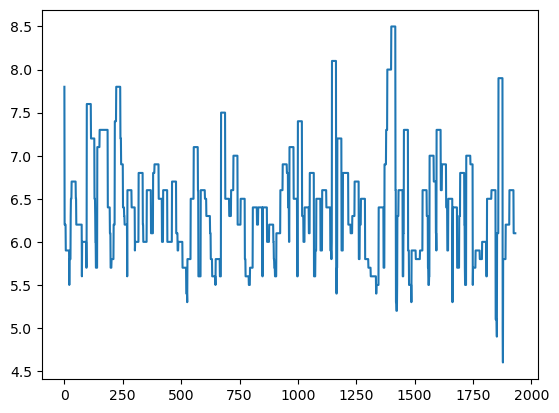

In [870]:
plt.plot(features_df['Mag_max'])

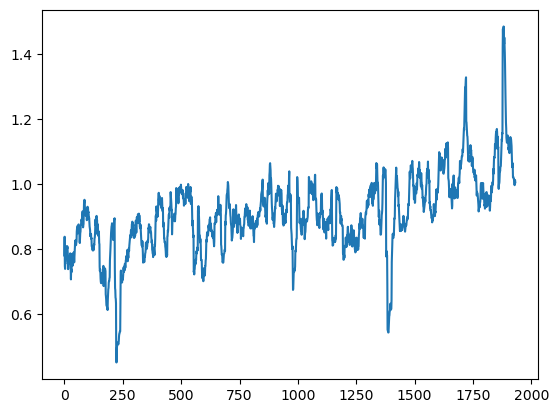

In [871]:
plt.plot(features_df['b_mlk'])

In [872]:
print(features_df.columns)

Index(['t', 'Num', 'Mag_max', 'Mag_max_obs', 'Mag_mean', 'b_lsq', 'a_lsq',
       'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
       'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
       'zvalue', 'beta', 'shock_len', 'Negative', 'T_elaps5', 'T_elaps5.5',
       'T_elaps6', 'T_elaps6.5'],
      dtype='object')


In [873]:
print(features_df['zvalue'])

0       1.838959
1       1.329298
2       1.453279
3       1.053895
4       0.341053
          ...   
1927    0.225702
1928    0.284702
1929   -0.060274
1930    0.932127
1931    1.246238
Name: zvalue, Length: 1932, dtype: float64


In [874]:
features_df

,t,Num,Mag_max,Mag_max_obs,Mag_mean,b_lsq,a_lsq,b_std_lsq,std_gr_lsq,b_mlk,...,prob_x7_lsq,prob_x7_mlk,zvalue,beta,shock_len,Negative,T_elaps5,T_elaps5.5,T_elaps6,T_elaps6.5
0,181.853333,954.0,7.8,5.9,3.556289,0.717267,1.474818,0.396859,22.171367,0.780699,...,0.007050,0.004549,1.838959,-22.124164,0.0,0.0,14.026921,110.763137,127.431424,177.811273
1,191.853333,508.0,6.2,5.9,3.518110,0.791030,1.584878,0.366668,17.095962,0.838228,...,0.004236,0.003057,1.329298,-10.829584,0.0,1.0,2.734931,120.763137,137.431424,187.811273
2,201.853333,357.0,6.2,5.9,3.580672,0.752067,1.532396,0.320777,15.516699,0.747917,...,0.005544,0.005705,1.453279,-5.828429,0.0,1.0,2.105404,130.763137,147.431424,197.811273
3,211.853333,325.0,6.2,5.5,3.587385,0.706845,1.522582,0.282365,13.647642,0.739370,...,0.007576,0.006052,1.053895,-4.305131,0.0,1.0,2.276281,2.276281,157.431424,207.811273
4,221.853333,317.0,6.2,5.5,3.573817,0.787135,1.501626,0.352653,17.225574,0.756852,...,0.004351,0.005363,0.341053,-0.781856,0.0,1.0,0.749212,12.276281,167.431424,217.811273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1927,19451.853333,996.0,6.1,4.7,3.431124,1.041758,1.696845,0.650344,29.297091,1.007353,...,0.000749,0.000950,0.225702,0.616317,0.0,1.0,34.904147,64.527193,64.527193,211.317014
1928,19461.853333,973.0,6.1,4.7,3.435766,1.039296,1.693578,0.645678,29.163433,0.996624,...,0.000762,0.001024,0.284702,0.363743,0.0,1.0,44.904147,74.527193,74.527193,221.317014
1929,19471.853333,929.0,6.1,4.7,3.429709,1.061836,1.657135,0.676162,30.672293,1.010670,...,0.000652,0.000929,-0.060274,1.682977,0.0,1.0,54.904147,84.527193,84.527193,231.317014
1930,19481.853333,918.0,6.1,4.7,3.429085,1.065426,1.644598,0.680967,30.928268,1.012141,...,0.000636,0.000920,0.932127,-2.058070,0.0,1.0,64.904147,94.527193,94.527193,241.317014


In [875]:
features_df[features_df['Num']==min(features_df['Num'])]

,t,Num,Mag_max,Mag_max_obs,Mag_mean,b_lsq,a_lsq,b_std_lsq,std_gr_lsq,b_mlk,...,prob_x7_lsq,prob_x7_mlk,zvalue,beta,shock_len,Negative,T_elaps5,T_elaps5.5,T_elaps6,T_elaps6.5
25,431.853333,290.0,5.8,6.7,3.551724,0.863410,1.559531,0.386066,18.501311,0.787159,...,0.002569,0.004350,0.442419,-1.069395,3.0,0.0,31.137656,31.137656,377.431424,427.811273
26,441.853333,290.0,5.8,6.7,3.560690,0.868193,1.562301,0.388269,18.705598,0.774572,...,0.002486,0.004746,0.350970,-0.599085,3.0,0.0,7.323102,41.137656,387.431424,437.811273


In [876]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(f_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [877]:
y_prob = rf.predict_proba(f_val)[:, 1]  # 取正类的概率
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

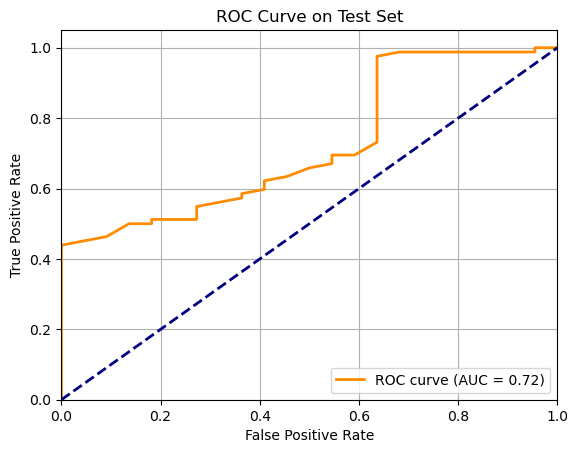

In [878]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # 参考线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(args.save_dir, 'roc_curve.png'))
plt.show()


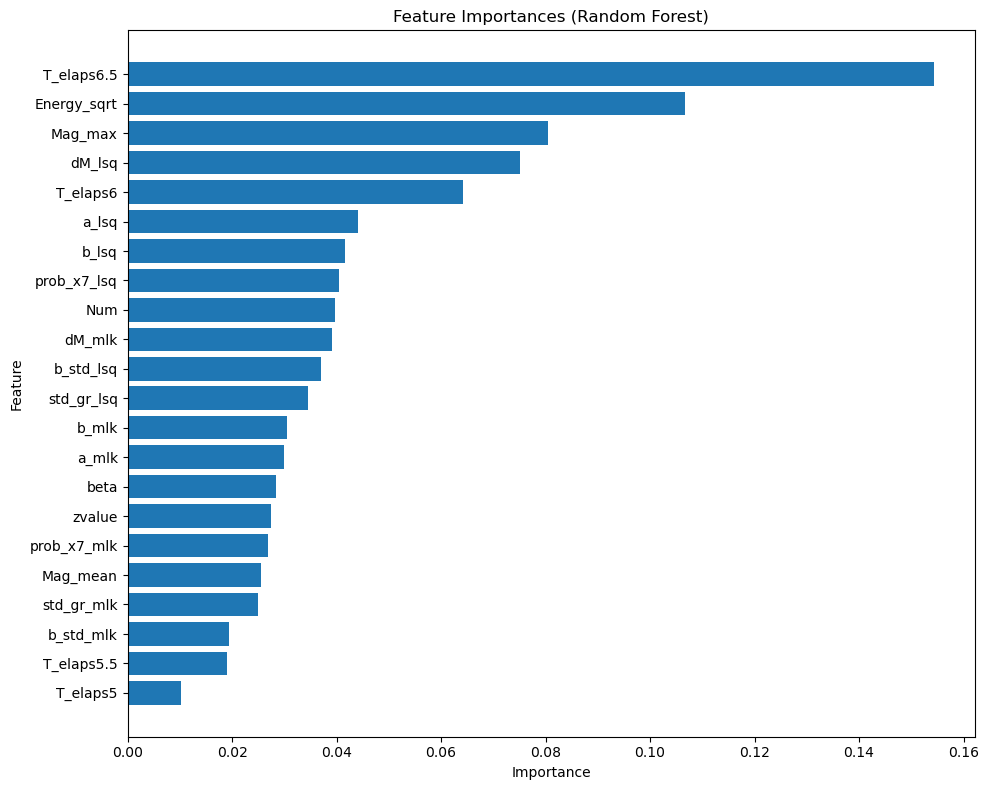

In [879]:
importances = rf.feature_importances_
feature_names = args.feature_cols

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[int(i)] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align="center")
plt.yticks(range(len(sorted_importances)), sorted_names)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.gca().invert_yaxis()  
plt.savefig(os.path.join(args.save_dir, 'feature_importances.png'))
plt.show()